# NorCal Atlas — Geodemographic Segmentation

This notebook reconstructs how an analysis-ready extract of **1,045 ZIP Code Tabulation Areas in a defined 50-county Northern and Central California study footprint** was clustered, tested, and compared with public vehicle and charging outcomes.

The model groups **places, not people**. It does not predict individual EV interest, customer behavior, or eligibility for any action.

## Summary

- Nine public demographic and household features define the clustering space.
- Vehicle adoption and charging access stay out of the clustering inputs and are profiled afterward.
- Separation is strongest at three to four groups; five groups are a deliberate interpretability tradeoff rather than a statistical optimum.
- Five broad families are stable enough for comparison.
- Eight descriptive subsegments add detail only where a documented split rule is met.
- Exact ZIP boundaries change under different algorithms and weighting choices.


The footprint runs from Del Norte and Siskiyou through Kern and San Luis Obispo. ‘NorCal’ is the project name, not a formal regional boundary.

## 1. Data and method

Four public source families form the place-level dataset.

| Source | Data used | Role in this notebook | Vintage |
|---|---|---|---|
| U.S. Census ACS | Population, income, age, housing, education, race/ethnicity, household composition | Clustering inputs | 2023 five-year estimates |
| California DMV | Registered vehicles, fuel mix, vehicle age | Held-out market outcomes | January 1, 2026 snapshot |
| USDA | Rural–Urban Continuum Codes | Geographic context; not a K-means input | 2023 |
| U.S. DOE AFDC | Public charging locations and distance | Held-out market comparison | May 27, 2026 snapshot |

**Reproducibility boundary:** the attached CSV is a curated, public-data-only analytical extract. This notebook reproduces the clustering, validation, profiles, and headline checks. It does not rerun the upstream downloads, geography joins, or map-geometry build.

**Ethical boundary:** race and ethnicity are included only to reproduce a historical descriptive geodemographic analysis. These public ACS place-level shares influence the clustering and some descriptive naming rules, so they are not neutral inputs and are not recommended for operational segmentation or place-based targeting. Do not use these groups to target, exclude, price, determine eligibility, or make decisions about people or neighborhoods. Any future decision use should first rerun the model without protected traits and undergo separate behavioral validation, fairness review, governance, and legal review.


### Setup

The notebook uses libraries that are standard in Colab. Their versions are displayed so the execution environment remains visible. The final reconciliation checks will fail if an environment change produces a different result.

In [1]:
from pathlib import Path
import platform
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn

from itertools import combinations
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import RobustScaler, StandardScaler

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

NAVY = "#1B2A4A"
BLUE = "#5B8DB8"
TEAL = "#1F6F5A"
GOLD = "#C08B2A"
RED = "#B22222"
GRAY = "#D8D8D4"
SEED = 42

pd.DataFrame(
    {
        "Component": ["Python", "pandas", "scikit-learn", "matplotlib"],
        "Version": [platform.python_version(), pd.__version__, sklearn.__version__, matplotlib.__version__],
    }
)

,Component,Version
0,Python,3.14.5
1,pandas,2.3.3
2,scikit-learn,1.9.0
3,matplotlib,3.11.1


### Load the prepared ZIP-level file

In [2]:
DATA_CANDIDATES = [
    Path("data/norcal_public_data.csv"),
    Path("../data/norcal_public_data.csv"),
]
DATA_FILE = next((path for path in DATA_CANDIDATES if path.exists()), None)

if DATA_FILE is None and "google.colab" in sys.modules:
    from google.colab import files

    print("Upload norcal_public_data.csv")
    uploaded = files.upload()
    if "norcal_public_data.csv" in uploaded:
        DATA_FILE = Path("norcal_public_data.csv")

if DATA_FILE is None:
    raise FileNotFoundError(
        "Could not find norcal_public_data.csv. Run from the repository root or "
        "the notebooks directory, or upload the CSV in Colab."
    )

data = pd.read_csv(DATA_FILE, dtype={"zcta": "string"})
data["zcta"] = data["zcta"].str.zfill(5)

print(f"{len(data):,} ZIPs loaded from {DATA_FILE}")
data[["zcta", "county", "population", "median_hh_income", "bev_pct", "total_vehicles_dmv"]].head(3)

1,045 ZIPs loaded from ../data/norcal_public_data.csv


,zcta,county,population,median_hh_income,bev_pct,total_vehicles_dmv
0,92328,Inyo,872.000,"91,198.000",1.540,195.000
1,92384,Inyo,18.000,NaN,1.820,55.000
2,92389,Inyo,169.000,"26,731.000",1.010,99.000


### Define the clustering inputs

The nine inputs describe the demographic and household structure of a place. Density is logged because its raw distribution has a long right tail.

Vehicle adoption, vehicle age, and charging access are held-out outcomes. They do not influence cluster assignment.


In [3]:
FEATURES = [
    "median_hh_income",
    "pct_ba_plus",
    "pct_asian_nh",
    "pct_hispanic",
    "median_age",
    "log_density",
    "owner_occupied_pct",
    "avg_vehicles_per_hh",
    "pct_hh_with_kids",
]

feature_guide = pd.DataFrame(
    {
        "Feature": FEATURES,
        "Plain-English meaning": [
            "Household income",
            "Adults with a bachelor's degree or higher",
            "Asian share of residents",
            "Hispanic share of residents",
            "Median resident age",
            "Population density on a log scale",
            "Share of occupied homes that are owner-occupied",
            "Average vehicles available per household",
            "Share of households with children",
        ],
    }
)
feature_guide

,Feature,Plain-English meaning
0,median_hh_income,Household income
1,pct_ba_plus,Adults with a bachelor's degree or higher
2,pct_asian_nh,Asian share of residents
3,pct_hispanic,Hispanic share of residents
4,median_age,Median resident age
5,log_density,Population density on a log scale
6,owner_occupied_pct,Share of occupied homes that are owner-occupied
7,avg_vehicles_per_hh,Average vehicles available per household
8,pct_hh_with_kids,Share of households with children


### Apply the population and complete-data rules

In [4]:
mapped_zips = len(data)
eligible = data.loc[data["population"] >= 1_000].copy()
model_data = eligible.dropna(subset=FEATURES).copy()
comparable = data.dropna(
    subset=["bev_pct", "median_hh_income", "home_charging_proxy", "nearest_dcfast_km"]
).copy()

scope = pd.DataFrame(
    {
        "Stage": ["Mapped ZIPs", "Population eligible", "Complete modeling cases", "Comparable BEV cases"],
        "ZIPs": [mapped_zips, len(eligible), len(model_data), len(comparable)],
        "Rule": [
            "Joined to the NorCal Atlas",
            "Population of at least 1,000",
            "No missing values across the nine inputs",
            "Complete values for the descriptive BEV comparisons",
        ],
    }
)
scope

,Stage,ZIPs,Rule
0,Mapped ZIPs,1045,Joined to the NorCal Atlas
1,Population eligible,761,"Population of at least 1,000"
2,Complete modeling cases,748,No missing values across the nine inputs
3,Comparable BEV cases,919,Complete values for the descriptive BEV compar...


In [5]:
missing_cases = eligible.loc[eligible[FEATURES].isna().any(axis=1), ["zcta", "county", "population", *FEATURES]].copy()
missing_cases["missing_inputs"] = missing_cases[FEATURES].isna().apply(
    lambda row: ", ".join(row.index[row].tolist()), axis=1
)
missing_cases[["zcta", "county", "population", "missing_inputs"]]

,zcta,county,population,missing_inputs
76,93410,San Luis Obispo,"7,038.000","median_hh_income, owner_occupied_pct, avg_vehi..."
79,93424,San Luis Obispo,"1,026.000",median_hh_income
209,93928,Monterey,"1,084.000","median_hh_income, owner_occupied_pct, avg_vehi..."
314,94528,Contra Costa,"1,000.000",median_hh_income
352,94575,Contra Costa,"1,005.000","median_hh_income, owner_occupied_pct, avg_vehi..."
397,94720,Alameda,"5,649.000",median_hh_income
408,94923,Sonoma,"1,457.000",median_hh_income
433,94964,Marin,"2,115.000",median_hh_income
467,95053,Santa Clara,"3,153.000",median_hh_income
515,95211,San Joaquin,"1,190.000","median_hh_income, owner_occupied_pct, avg_vehi..."


## 2. Standardize the inputs

K-means uses distance. Standardization places every feature on the same scale so income does not dominate percentages or household counts.

In [6]:
X = model_data[FEATURES].to_numpy(dtype=float)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scale_check = pd.DataFrame(
    {
        "feature": FEATURES,
        "raw_mean": X.mean(axis=0),
        "standardized_mean": X_scaled.mean(axis=0),
        "standardized_std": X_scaled.std(axis=0),
    }
)
scale_check

,feature,raw_mean,standardized_mean,standardized_std
0,median_hh_income,"101,943.930",0.000,1.000
1,pct_ba_plus,34.866,-0.000,1.000
2,pct_asian_nh,11.435,-0.000,1.000
3,pct_hispanic,30.375,-0.000,1.000
4,median_age,40.929,-0.000,1.000
5,log_density,5.209,0.000,1.000
6,owner_occupied_pct,62.678,-0.000,1.000
7,avg_vehicles_per_hh,2.043,0.000,1.000
8,pct_hh_with_kids,31.605,-0.000,1.000


## 3. Compare possible numbers of groups

No single diagnostic decides the right number of clusters.

- **Silhouette:** separation between groups. Higher is better.
- **Calinski–Harabasz:** compact groups separated from one another. Higher is better.
- **Davies–Bouldin:** similarity between groups. Lower is better.
- **Inertia:** distance from each ZIP to its group center. Lower is better, but it always falls as more groups are added.

In [7]:
def fit_kmeans(values, groups, seed=SEED, restarts=25, sample_weight=None):
    model = KMeans(
        n_clusters=groups,
        init="k-means++",
        n_init=restarts,
        random_state=seed,
    )
    return model.fit(values, sample_weight=sample_weight)


k_rows = []
for groups in range(2, 11):
    model = fit_kmeans(X_scaled, groups)
    labels = model.labels_
    k_rows.append(
        {
            "K": groups,
            "Silhouette": silhouette_score(X_scaled, labels),
            "Calinski-Harabasz": calinski_harabasz_score(X_scaled, labels),
            "Davies-Bouldin": davies_bouldin_score(X_scaled, labels),
            "Inertia": model.inertia_,
        }
    )

k_results = pd.DataFrame(k_rows)
k_results.round(4)

,K,Silhouette,Calinski-Harabasz,Davies-Bouldin,Inertia
0,2,0.267,239.688,1.518,"5,094.992"
1,3,0.280,299.169,1.226,"3,733.490"
2,4,0.282,272.170,1.257,"3,209.635"
3,5,0.232,253.758,1.302,"2,845.156"
4,6,0.215,233.375,1.363,"2,616.800"
5,7,0.219,220.809,1.327,"2,414.700"
6,8,0.219,208.986,1.312,"2,261.415"
7,9,0.211,200.937,1.317,"2,120.163"
8,10,0.214,194.471,1.287,"1,996.680"


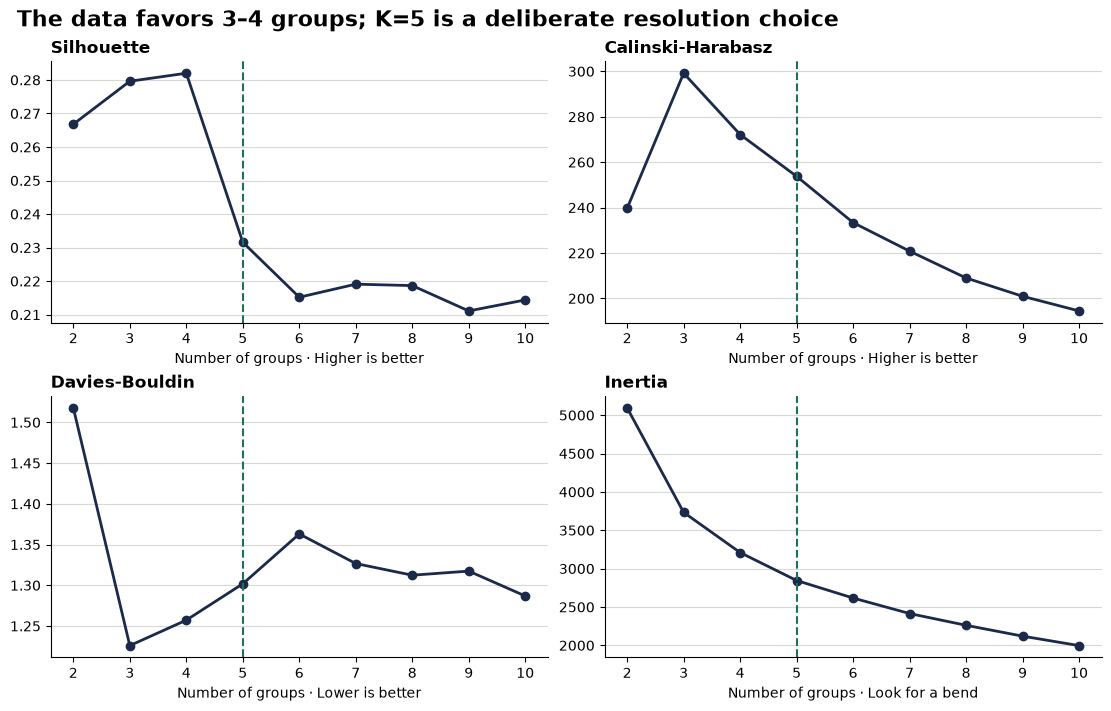

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
charts = [
    ("Silhouette", "Higher is better"),
    ("Calinski-Harabasz", "Higher is better"),
    ("Davies-Bouldin", "Lower is better"),
    ("Inertia", "Look for a bend"),
]

for axis, (metric, note) in zip(axes.flat, charts):
    axis.plot(k_results["K"], k_results[metric], marker="o", color=NAVY, linewidth=2)
    axis.axvline(5, color=TEAL, linestyle="--", linewidth=1.5)
    axis.set_title(metric, loc="left", fontweight="bold")
    axis.set_xlabel(f"Number of groups · {note}")
    axis.grid(axis="y", color=GRAY, linewidth=0.8)
    axis.spines[["top", "right"]].set_visible(False)

fig.suptitle("The data favors 3–4 groups; K=5 is a deliberate resolution choice", x=0.01, ha="left", fontsize=16, fontweight="bold")
plt.show()

**Read:** silhouette favors four groups, while Calinski–Harabasz and Davies–Bouldin favor three. All three indicate stronger separation at three to four groups than at five. The five-family layer is therefore not presented as a statistical optimum. It is a deliberate tradeoff: one additional, business-relevant family is retained because the next section shows that the five-group solution remains reproducible.

## 4. Test the five-family structure

Adjusted Rand Index (ARI) measures agreement between two cluster assignments. A score of 1 means the assignments are identical.

The checks answer different questions:

- Repeated starts and subsamples test whether the same method finds the same structure.
- Alternative algorithms, weighting, and scaling test whether the exact boundaries depend on modeling choices.

In [9]:
def initialization_stability(values, groups=5, runs=50):
    labels = [fit_kmeans(values, groups, seed=seed, restarts=1).labels_ for seed in range(runs)]
    scores = [adjusted_rand_score(labels[i], labels[j]) for i, j in combinations(range(runs), 2)]
    return float(np.mean(scores))


def subsample_stability(values, draws=25, fraction=0.85):
    rng = np.random.default_rng(SEED)
    sample_size = int(round(fraction * len(values)))
    results = {}
    for groups in (4, 5, 6):
        full_labels = fit_kmeans(values, groups).labels_
        scores = []
        for _ in range(draws):
            rows = rng.choice(len(values), size=sample_size, replace=False)
            sample_labels = fit_kmeans(values[rows], groups).labels_
            scores.append(adjusted_rand_score(full_labels[rows], sample_labels))
        results[groups] = float(np.mean(scores))
    return results


parent_model = fit_kmeans(X_scaled, 5)
parent_labels = parent_model.labels_

ward_labels = AgglomerativeClustering(n_clusters=5, linkage="ward").fit(X_scaled).labels_
robust_values = RobustScaler().fit_transform(X)
robust_labels = fit_kmeans(robust_values, 5).labels_
weighted_labels = fit_kmeans(
    X_scaled,
    5,
    sample_weight=model_data["population"].to_numpy(dtype=float),
).labels_

# Race and ethnicity are public place-level descriptors here, not individual traits.
# This sensitivity check makes their influence on the exact assignments explicit.
protected_descriptors = {"pct_asian_nh", "pct_hispanic"}
reduced_features = [feature for feature in FEATURES if feature not in protected_descriptors]
reduced_values = StandardScaler().fit_transform(model_data[reduced_features])
reduced_labels = fit_kmeans(reduced_values, 5).labels_
protected_descriptor_ari = adjusted_rand_score(parent_labels, reduced_labels)
reduced_silhouette = silhouette_score(reduced_values, reduced_labels)

robustness = pd.DataFrame(
    {
        "Check": [
            "Different starting points",
            "85% subsamples",
            "RobustScaler",
            "Ward clustering",
            "Population weighting",
            "Exclude race/ethnicity descriptors",
        ],
        "ARI": [
            initialization_stability(X_scaled),
            subsample_stability(X_scaled)[5],
            adjusted_rand_score(parent_labels, robust_labels),
            adjusted_rand_score(parent_labels, ward_labels),
            adjusted_rand_score(parent_labels, weighted_labels),
            protected_descriptor_ari,
        ],
        "Question": [
            "Does K-means return to the same solution?",
            "Does the structure survive a smaller sample?",
            "Does the scaling choice change the result?",
            "Does another clustering method draw the same boundaries?",
            "Does weighting people instead of ZIPs change the result?",
            "How much do protected place descriptors affect exact assignments?",
        ],
    }
)
robustness.round(3)

,Check,ARI,Question
0,Different starting points,0.872,Does K-means return to the same solution?
1,85% subsamples,0.928,Does the structure survive a smaller sample?
2,RobustScaler,0.881,Does the scaling choice change the result?
3,Ward clustering,0.488,Does another clustering method draw the same b...
4,Population weighting,0.531,Does weighting people instead of ZIPs change t...
5,Exclude race/ethnicity descriptors,0.566,How much do protected place descriptors affect...


**Read:** the five-family structure is reproducible under repeated starts and subsamples. Exact ZIP boundaries are more sensitive to the algorithm, population weighting, and feature choice.

Removing the two race/ethnicity descriptors changes the exact K=5 assignments materially (`ARI ≈ 0.57`) and slightly improves silhouette (`0.243` versus `0.232`). That is counter-evidence against treating the published clusters as neutral or inevitable. It reinforces the research-only boundary: use the model to compare places and form hypotheses, not to make decisions about people.

## 5. Name the five place families

Numeric cluster labels have no meaning. Descriptive names are assigned from explicit feature signatures such as high income, urban density and renting, rural density and older age, or younger Valley households.

The names are communication aids, not claims that every place or resident fits a stereotype. The underlying profiles and uncertainty matter more than the labels.


In [10]:
raw_parent_profiles = {
    label: dict(zip(FEATURES, X[parent_labels == label].mean(axis=0)))
    for label in sorted(set(parent_labels))
}

family_naming_rules = [
    ("High-income technology suburbs", lambda profile: profile["median_hh_income"] > 140_000 and profile["pct_asian_nh"] > 25, "Income > $140k and Asian share > 25%"),
    ("Dense renter cities", lambda profile: np.exp(profile["log_density"]) > 3_000 and profile["owner_occupied_pct"] < 45, "Density > 3,000/km² and owner occupancy < 45%"),
    ("Rural and small-town owners", lambda profile: np.exp(profile["log_density"]) < 200 and profile["median_age"] > 47, "Density < 200/km² and median age > 47"),
    ("Younger Valley families", lambda profile: profile["pct_hispanic"] > 60 and profile["median_age"] < 34, "Hispanic share > 60% and median age < 34"),
]

parent_name_by_label = {}
naming_rule_by_label = {}
for family_name, rule, rule_text in family_naming_rules:
    matches = [label for label, profile in raw_parent_profiles.items() if rule(profile)]
    assert len(matches) == 1, f"Naming rule for {family_name} matched {len(matches)} groups."
    parent_name_by_label[matches[0]] = family_name
    naming_rule_by_label[matches[0]] = rule_text

residual = [label for label in raw_parent_profiles if label not in parent_name_by_label]
assert len(residual) == 1, "Expected one residual place family."
parent_name_by_label[residual[0]] = "Middle-income suburbs"
naming_rule_by_label[residual[0]] = "The remaining middle-income suburban group"
model_data["model_parent"] = [parent_name_by_label[label] for label in parent_labels]

parent_signatures = pd.DataFrame([
    {
        "Family": parent_name_by_label[label],
        "Naming rule": naming_rule_by_label[label],
        "Income": profile["median_hh_income"],
        "Asian %": profile["pct_asian_nh"],
        "Hispanic %": profile["pct_hispanic"],
        "Median age": profile["median_age"],
        "Density / km²": np.exp(profile["log_density"]),
        "Owner occupied %": profile["owner_occupied_pct"],
    }
    for label, profile in raw_parent_profiles.items()
]).sort_values("Income", ascending=False)
display(parent_signatures.round(1))


,Family,Naming rule,Income,Asian %,Hispanic %,Median age,Density / km²,Owner occupied %
1,High-income technology suburbs,Income > $140k and Asian share > 25%,"173,355.200",31.600,15.600,42.400,915.000,70.600
0,Dense renter cities,"Density > 3,000/km² and owner occupancy < 45%","125,121.000",24.600,18.900,36.900,"3,524.000",32.400
3,Rural and small-town owners,Density < 200/km² and median age > 47,"90,332.300",2.100,15.400,50.600,22.700,77.500
4,Middle-income suburbs,The remaining middle-income suburban group,"86,400.800",8.900,33.400,37.300,274.600,59.400
2,Younger Valley families,Hispanic share > 60% and median age < 34,"62,627.400",3.800,74.500,31.100,117.800,50.900


### Compare the parent families

In [11]:
def weighted_mean(group, value, weight):
    valid = group[[value, weight]].dropna()
    if valid.empty or valid[weight].sum() == 0:
        return np.nan
    return np.average(valid[value], weights=valid[weight])


def summarize_groups(frame, group_column):
    rows = []
    for name, group in frame.groupby(group_column, sort=False):
        rows.append({
            "Group": name,
            "ZIPs": len(group),
            "Population": group["population"].sum(),
            "Income": weighted_mean(group, "median_hh_income", "households"),
            "Median age": weighted_mean(group, "median_age", "population"),
            "Owner occupied %": weighted_mean(group, "owner_occupied_pct", "households"),
            "BEV %": weighted_mean(group, "bev_pct", "total_vehicles_dmv"),
            "Newer-fleet BEV %": weighted_mean(group, "pct_new_BEV", "total_vehicles_dmv"),
            "Vehicle age": weighted_mean(group, "avg_vehicle_age", "total_vehicles_dmv"),
        })
    return pd.DataFrame(rows).sort_values("Income", ascending=False).reset_index(drop=True)

parent_summary = summarize_groups(model_data, "model_parent")
parent_summary.round({"Income": 0, "Median age": 1, "Owner occupied %": 1, "BEV %": 1, "Newer-fleet BEV %": 1, "Vehicle age": 1})


,Group,ZIPs,Population,Income,Median age,Owner occupied %,BEV %,Newer-fleet BEV %,Vehicle age
0,High-income technology suburbs,126,"4,230,225.000","166,336.000",41.200,68.000,11.100,32.600,6.800
1,Dense renter cities,67,"1,764,249.000","128,239.000",36.900,34.200,9.500,29.600,7.000
2,Rural and small-town owners,212,"1,456,352.000","95,302.000",49.000,74.800,3.200,14.000,7.600
3,Middle-income suburbs,227,"6,624,356.000","89,407.000",37.000,58.600,3.400,14.800,7.500
4,Younger Valley families,116,"2,608,223.000","67,227.000",31.600,53.300,1.400,7.500,7.700


## 6. Add descriptive subsegments

The broad families are the stable comparison layer. A family splits into two subsegments only when:

1. each side contains at least 25 ZIPs; and
2. the sides differ by a documented margin on ethnicity, density, or ownership.

The rule splits three families and leaves two families whole, producing eight descriptive subsegments. These narrower boundaries are less stable than the five-family layer.


In [12]:
MIN_SUBGROUP = 25
SPLIT_MARGINS = {"pct_asian_nh": 15.0, "pct_hispanic": 18.0, "log_density": 1.0, "owner_occupied_pct": 18.0}
SUPPORTED_SPLITS = {
    "High-income technology suburbs",
    "Middle-income suburbs",
    "Younger Valley families",
}
model_segments = np.empty(len(model_data), dtype=object)
split_rows = []

for parent_name in model_data["model_parent"].unique():
    positions = np.flatnonzero(model_data["model_parent"].to_numpy() == parent_name)
    model_segments[positions] = parent_name  # Safe default: keep the parent family intact.

    sub_labels = fit_kmeans(X_scaled[positions], 2).labels_
    first = positions[sub_labels == 0]
    second = positions[sub_labels == 1]
    means_first = dict(zip(FEATURES, X[first].mean(axis=0)))
    means_second = dict(zip(FEATURES, X[second].mean(axis=0)))
    differences = {name: abs(means_first[name] - means_second[name]) for name in SPLIT_MARGINS}
    fired = [name for name, margin in SPLIT_MARGINS.items() if differences[name] >= margin]
    should_split = min(len(first), len(second)) >= MIN_SUBGROUP and bool(fired)

    if should_split and parent_name not in SUPPORTED_SPLITS:
        raise AssertionError(f"A split fired for {parent_name}, but no naming rule is defined.")
    if should_split and parent_name == "High-income technology suburbs":
        high, low = (first, second) if means_first["pct_asian_nh"] >= means_second["pct_asian_nh"] else (second, first)
        model_segments[high] = "High-income technology corridor"
        model_segments[low] = "Established high-income suburbs"
    elif should_split and parent_name == "Middle-income suburbs":
        high, low = (first, second) if means_first["log_density"] >= means_second["log_density"] else (second, first)
        model_segments[high] = "Inner-ring middle-income suburbs"
        model_segments[low] = "Exurban middle-income communities"
    elif should_split and parent_name == "Younger Valley families":
        high, low = (first, second) if means_first["log_density"] >= means_second["log_density"] else (second, first)
        model_segments[high] = "Urban Valley renters"
        model_segments[low] = "Rural Valley family owners"

    split_rows.append({
        "Parent family": parent_name,
        "Smallest side": min(len(first), len(second)),
        "Margins met": ", ".join(fired) if fired else "None",
        "Decision": "Split" if should_split else "Keep whole",
    })

model_data["model_segment"] = model_segments
pd.DataFrame(split_rows).sort_values("Parent family")

,Parent family,Smallest side,Margins met,Decision
4,Dense renter cities,22,owner_occupied_pct,Keep whole
3,High-income technology suburbs,60,pct_asian_nh,Split
1,Middle-income suburbs,107,log_density,Split
2,Rural and small-town owners,91,None,Keep whole
0,Younger Valley families,28,log_density,Split


In [13]:
segment_counts = (
    model_data.groupby(["model_parent", "model_segment"], as_index=False)
    .agg(ZIPs=("zcta", "size"), Population=("population", "sum"))
    .rename(columns={"model_parent": "Parent family", "model_segment": "Descriptive subsegment"})
    .sort_values(["Parent family", "Descriptive subsegment"])
)

print(f"{model_data['model_parent'].nunique()} parent families → {model_data['model_segment'].nunique()} descriptive subsegments")
segment_counts

5 parent families → 8 descriptive subsegments


,Parent family,Descriptive subsegment,ZIPs,Population
0,Dense renter cities,Dense renter cities,67,"1,764,249.000"
1,High-income technology suburbs,Established high-income suburbs,66,"1,748,727.000"
2,High-income technology suburbs,High-income technology corridor,60,"2,481,498.000"
3,Middle-income suburbs,Exurban middle-income communities,120,"2,373,445.000"
4,Middle-income suburbs,Inner-ring middle-income suburbs,107,"4,250,911.000"
5,Rural and small-town owners,Rural and small-town owners,212,"1,456,352.000"
6,Younger Valley families,Rural Valley family owners,88,"1,888,674.000"
7,Younger Valley families,Urban Valley renters,28,"719,549.000"


In [14]:
segment_summary = summarize_groups(model_data, "model_segment")
segment_summary.round({"Income": 0, "Median age": 1, "Owner occupied %": 1, "BEV %": 1, "Newer-fleet BEV %": 1, "Vehicle age": 1})


,Group,ZIPs,Population,Income,Median age,Owner occupied %,BEV %,Newer-fleet BEV %,Vehicle age
0,Established high-income suburbs,66,"1,748,727.000","175,387.000",42.800,73.100,11.000,31.300,6.800
1,High-income technology corridor,60,"2,481,498.000","159,334.000",40.000,64.200,11.200,33.600,6.800
2,Dense renter cities,67,"1,764,249.000","128,239.000",36.900,34.200,9.500,29.600,7.000
3,Rural and small-town owners,212,"1,456,352.000","95,302.000",49.000,74.800,3.200,14.000,7.600
4,Exurban middle-income communities,120,"2,373,445.000","92,754.000",38.000,66.000,3.000,12.500,7.400
5,Inner-ring middle-income suburbs,107,"4,250,911.000","87,527.000",36.400,54.500,3.700,16.300,7.500
6,Rural Valley family owners,88,"1,888,674.000","70,617.000",31.600,57.700,1.400,7.300,7.700
7,Urban Valley renters,28,"719,549.000","59,270.000",31.600,43.100,1.400,8.000,7.900


## 7. Add outcomes that were held out of clustering

These relationships describe the market. They do not establish causality or individual intent.

The comparable sample contains ZIPs with complete BEV adoption, income, home-charging proxy, and DC-fast-charger-distance values.

In [15]:
comparable["nearest_dcfast_miles"] = comparable["nearest_dcfast_km"] * 0.621371

correlations = pd.DataFrame(
    {
        "Relationship": [
            "BEV share and household income",
            "BEV share and distance to a DC-fast charger",
            "BEV share and the home-charging proxy",
        ],
        "Pearson correlation": [
            comparable["bev_pct"].corr(comparable["median_hh_income"]),
            comparable["bev_pct"].corr(comparable["nearest_dcfast_miles"]),
            comparable["bev_pct"].corr(comparable["home_charging_proxy"]),
        ],
        "ZIPs": [len(comparable)] * 3,
    }
)
correlations.round(3)

,Relationship,Pearson correlation,ZIPs
0,BEV share and household income,0.789,919
1,BEV share and distance to a DC-fast charger,-0.418,919
2,BEV share and the home-charging proxy,-0.038,919


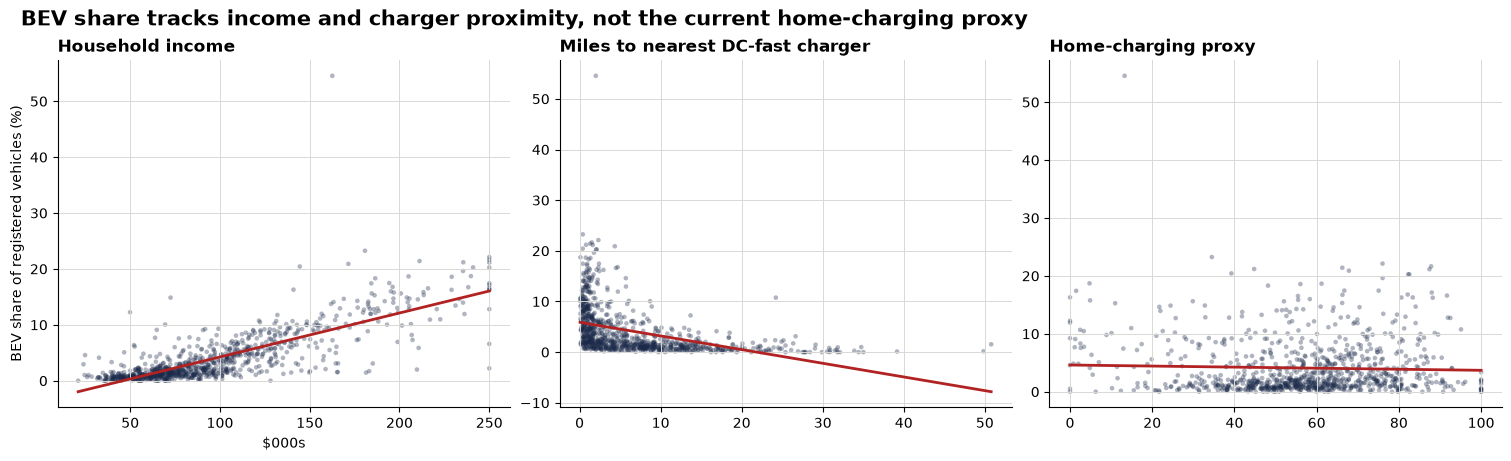

In [16]:
relationships = [
    ("median_hh_income", "Household income", 1_000),
    ("nearest_dcfast_miles", "Miles to nearest DC-fast charger", 1),
    ("home_charging_proxy", "Home-charging proxy", 1),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
for axis, (x_column, x_label, scale) in zip(axes, relationships):
    x = comparable[x_column].to_numpy(dtype=float) / scale
    y = comparable["bev_pct"].to_numpy(dtype=float)
    axis.scatter(x, y, s=11, alpha=0.35, color=NAVY, edgecolors="none")
    slope, intercept = np.polyfit(x, y, 1)
    line_x = np.linspace(x.min(), x.max(), 100)
    axis.plot(line_x, slope * line_x + intercept, color=RED, linewidth=2)
    axis.set_title(x_label, loc="left", fontweight="bold")
    axis.set_xlabel("$000s" if x_column == "median_hh_income" else "")
    axis.set_ylabel("BEV share of registered vehicles (%)" if axis is axes[0] else "")
    axis.grid(color=GRAY, linewidth=0.7)
    axis.spines[["top", "right"]].set_visible(False)

fig.suptitle("BEV share tracks income and charger proximity, not the current home-charging proxy", x=0.01, ha="left", fontsize=15, fontweight="bold")
plt.show()

## 8. Appropriate use

| Supported by this work | Useful next hypothesis | Not supported |
|---|---|---|
| Compare place-based market conditions | Select contrasting places for additional research | Predict an individual's EV interest |
| Describe broad family-level patterns | Test whether geography adds useful context to a separate model | Treat cluster boundaries as natural laws |
| Profile held-out public vehicle and charging outcomes | Re-run the analysis with alternate feature sets | Claim that observed relationships are causal |

**Confidence gradient**

- Continuous market axes: highest confidence
- Five place families: high to moderate confidence
- Eight subsegments: moderate confidence
- Exact ZIP boundaries: lower confidence

The model is best used to decide where to investigate next. Any decision affecting people would require behavioral evidence, fairness review, governance, and an appropriate measurement design.


## 9. Reconciliation checks

In [17]:
checks = {
    "Mapped ZIPs": len(data) == 1_045,
    "Population-eligible ZIPs": len(eligible) == 761,
    "Complete modeling cases": len(model_data) == 748,
    "Comparable BEV cases": len(comparable) == 919,
    "Five place families": model_data["model_parent"].nunique() == 5,
    "Eight descriptive subsegments": model_data["model_segment"].nunique() == 8,
    "Protected-feature sensitivity reconciles": np.isclose(protected_descriptor_ari, 0.5662, atol=0.0001),
    "K=5 silhouette reconciles": np.isclose(k_results.loc[k_results["K"] == 5, "Silhouette"].iloc[0], 0.2316, atol=0.0001),
    "Income correlation reconciles": np.isclose(correlations.loc[0, "Pearson correlation"], 0.79, atol=0.01),
    "Charger-distance correlation reconciles": np.isclose(correlations.loc[1, "Pearson correlation"], -0.42, atol=0.01),
    "Home-charging correlation reconciles": np.isclose(correlations.loc[2, "Pearson correlation"], -0.04, atol=0.01),
}
check_table = pd.DataFrame({"Check": checks.keys(), "Passed": checks.values()})
display(check_table)
assert all(checks.values()), "One or more reconciliation checks failed."
print("All reconciliation checks passed.")


,Check,Passed
0,Mapped ZIPs,True
1,Population-eligible ZIPs,True
2,Complete modeling cases,True
3,Comparable BEV cases,True
4,Five place families,True
5,Eight descriptive subsegments,True
6,Protected-feature sensitivity reconciles,True
7,K=5 silhouette reconciles,True
8,Income correlation reconciles,True
9,Charger-distance correlation reconciles,True


All reconciliation checks passed.


## Project links

- [Open the interactive NorCal Atlas on GitHub Pages](https://lgoyal13.github.io/norcal-atlas/)
- [Return to the GitHub project overview](https://github.com/lgoyal13/norcal-atlas)
